<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/21_Ridge_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [4]:
data=load_diabetes()

In [8]:
X=data.data
y=data.target

In [9]:
X.shape

(442, 10)

In [10]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2 , random_state=42)

In [11]:
lr=LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred=lr.predict(X_test)

In [13]:
r2_score(y_test,y_pred)

0.4526027629719195

In [15]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(53.85344583676593)

In [16]:
lr.coef_


array([  37.90402135, -241.96436231,  542.42875852,  347.70384391,
       -931.48884588,  518.06227698,  163.41998299,  275.31790158,
        736.1988589 ,   48.67065743])

In [17]:
lr.intercept_

np.float64(151.34560453985995)

In [18]:
rg=Ridge(alpha=0.001)
rg.fit(X_train, y_train)

Ridge(alpha=0.001)

In [67]:
y_pred1=rg.predict(X_test)

In [20]:
np.sqrt(mean_squared_error(y_test,y_pred1))

np.float64(53.81283525336318)

In [22]:
r2_score(y_test,y_pred1)

0.4534280301019329

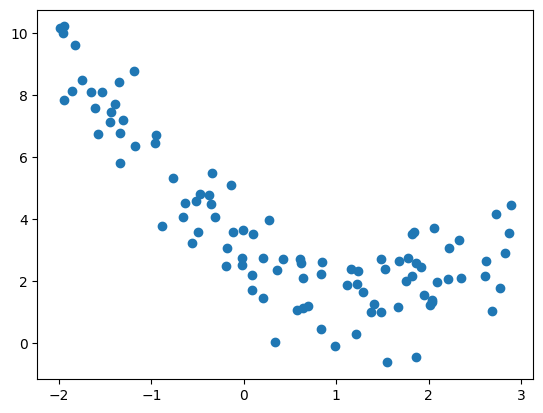

In [23]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

In [33]:
def get_preds_ridge(x1,x2,alpha):

  ploy_fet=PolynomialFeatures(degree=16)
  ridge=Ridge(alpha=alpha)

  ridge_final=Pipeline([
      ("ploy_fet",ploy_fet),
      ("ridge",ridge)
  ])
  ridge_final.fit(x1,x2)

  return ridge_final.predict(x1)



In [34]:
alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

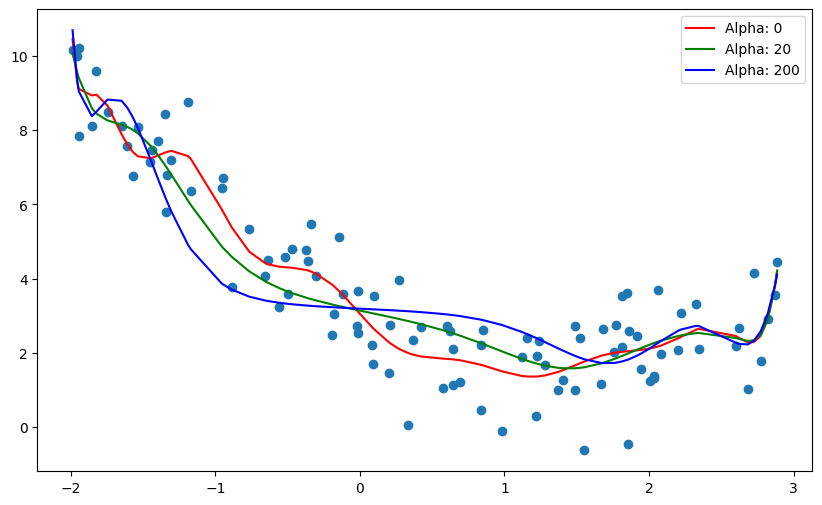

In [69]:
plt.figure(figsize=(10, 6))
plt.scatter(x1, x2)
for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()